In [75]:
from utils import *
from sintonia import * 
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from functools import partial
from numba import njit
from typing import Tuple
from numpy.linalg import inv
from scipy.stats import chi2
import os 

# Algorítmo Adaptado para Caso de Trajetórias

O algorítmo original de identificação das matrizes de covariância foi projetado para o Caso linear, portanto, é necessário gerar adaptações do algorítmo para tentar simular ele num caso não linear.

O artigo original não garante convergência para casos não-lineares, sendo, portanto um trabalho futuro dos autores.

Para viabilizar a identificação das covariâncias de ruído, propõe-se uma aproximação por ponto de operação nominal médio. Esta técnica permite estabilizar a geometria do problema de otimização, viabilizando a estimativa da covariância de predição estacionária ($\bar{\mathbf{P}}$) e a avaliação das funções objetivo. No processamento em lote (\textit{batch}), a dinâmica média é representada pelos Jacobianos médios da trajetória:

$$
\hat{\mathbf{F}} = \frac{1}{N} \sum_{k=1}^{N} \left. \frac{\partial \mathbf{f}}{\partial \mathbf{x}} \right|_{\hat{\mathbf{x}}_k}, \quad \hat{\mathbf{H}} = \frac{1}{N} \sum_{k=1}^{N} \left. \frac{\partial \mathbf{h}}{\partial \mathbf{x}} \right|_{\hat{\mathbf{x}}_k}
$$

## 1.1 Adaptação Inicial da função geradora de Resíduos

In [79]:
class EKF:
    """
    Filtro de Kalman Estendido genérico.
    - Q e R devem ser matrizes de dimensão (nx,nx) e (nz,nz), respectivamente.
    - Gamma é ignorado no predict (usado apenas para compatibilidade externa).
    """
    def __init__(self, x0, P0, f_func, F_jac, h_func, H_jac, Q, R, Gamma=None):
        self.x = x0.copy()
        self.P = P0.copy()
        self.f_func = f_func
        self.F_jac = F_jac
        self.h_func = h_func
        self.H_jac = H_jac
        self.Q = Q if callable(Q) else lambda x: Q
        self.R = R if callable(R) else lambda x: R
        self.nu = None
        self.mu = None

    def predict(self):
        F = self.F_jac(self.x)
        self.x = self.f_func(self.x)
        # Adição direta de Q (já deve ser 6x6)
        self.P = F @ self.P @ F.T + self.Q(self.x)

    def update(self, z, *args, **kwargs):
        H = self.H_jac(self.x, *args, **kwargs)
        z_pred = self.h_func(self.x, *args, **kwargs)
        y = z - z_pred                     # inovação

        S = H @ self.P @ H.T + self.R(self.x)
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(len(self.x)) - K @ H) @ self.P

        self.nu = y                        # inovação (pré-ajuste)
        self.mu = z - self.h_func(self.x, *args, **kwargs)  # resíduo pós-ajuste

        return self.nu, self.mu

In [76]:
def generate_residuals_ekf(Z, f_func, h_func, F_jac, H_jac, Q, R, x0_hat):
    """
    Versão EKF para gerar inovações e resíduos.
    f_func: função de transição de estados x_{k+1} = f(x_k)
    h_func: função de medição z_k = h(x_k)
    """
    N, nz = Z.shape
    nx = x0_hat.shape[0]
    nu = np.zeros((N, nz))
    mu = np.zeros((N, nz))
    x_hat = x0_hat.copy()
    P = np.eye(nx) # Inicialização simples

    for k in range(N):
        # 1. Predição
        x_pred = f_func(x_hat)
        F_k = F_jac(x_hat)
        P_pred = F_k @ P @ F_k.T + Q
        
        # 2. Inovação (nu)
        z_k = Z[k].reshape(nz, 1)
        nu_k = z_k - h_func(x_pred)
        
        # 3. Ganho e Atualização
        H_k = H_jac(x_pred)
        S_k = H_k @ P_pred @ H_k.T + R
        K_k = P_pred @ H_k.T @ np.linalg.inv(S_k)
        
        x_hat = x_pred + K_k @ nu_k
        P = (np.eye(nx) - K_k @ H_k) @ P_pred
        
        # 4. Resíduo Pós-ajuste (mu)
        mu_k = z_k - h_func(x_hat)
        
        nu[k] = nu_k.flatten()
        mu[k] = mu_k.flatten()
        
    return nu, mu

In [77]:
def find_average_operation_points(estados_estimados, antenas_base, F_jac_func, H_jac_func):
    """
    Calcula os Jacobianos médios ao longo da trajetória estimada.
    F_jac_func: função que recebe estado (vetor coluna) e retorna matriz Jacobiana de f.
    H_jac_func: função que recebe estado e antenas, retorna Jacobiano de h.
    """
    N = len(estados_estimados)
    list_F = []
    list_H = []

    for k in range(N):
        x_k = estados_estimados[k, :].reshape(-1, 1)
        F_k = F_jac_func(x_k)
        H_k = H_jac_func(x_k, antenas_base)
        list_F.append(F_k)
        list_H.append(H_k)

    F_medio = np.mean(list_F, axis=0)
    H_medio = np.mean(list_H, axis=0)
    return F_medio, H_medio

## 1.2. Exemplo Adaptação de métodos para cálculo dos jacobianos e Jacobianos médios

In [78]:
def f_pva(x, dt):
    """Modelo de transição de estado para PVA (Posição-Velocidade-Aceleração)."""
    A = np.array([[0, 0, 1, 0, 0, 0],
                  [0, 0, 0, 1, 0, 0],
                  [0, 0, 0, 0, 1, 0],
                  [0, 0, 0, 0, 0, 1],
                  [0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0]])
    F = expm(A * dt)
    return F @ x

def F_jac_pva(x, dt):
    """Jacobiano da função de transição (constante para modelo PVA linear)."""
    A = np.array([[0, 0, 1, 0, 0, 0],
                  [0, 0, 0, 1, 0, 0],
                  [0, 0, 0, 0, 1, 0],
                  [0, 0, 0, 0, 0, 1],
                  [0, 0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0, 0]])
    return expm(A * dt)

def h_pva(x, bases):
    """Função de observação: distâncias até as antenas."""
    px, py = x[0, 0], x[1, 0]
    dists = np.sqrt((px - bases[:, 0])**2 + (py - bases[:, 1])**2)
    return dists.reshape(-1, 1)

def H_jac_pva(x, bases):
    """Jacobiano da função de observação."""
    px, py = x[0, 0], x[1, 0]
    n = bases.shape[0]
    H = np.zeros((n, 6))
    for i, (bx, by) in enumerate(bases):
        dx = px - bx
        dy = py - by
        d = np.sqrt(dx**2 + dy**2)
        if d > 1e-8:
            H[i, 0] = dx / d
            H[i, 1] = dy / d
    return H

## Implementação do algorítmo completo

In [80]:
def executar_simulacao_ekf(tipo_teste, t_sim, traj_gt, antenas_base,
                           f_func, F_jac, h_func, H_jac,
                           Q, R, x0, P0, Gamma, dT_sim=1.0):
    """
    Executa simulação do EKF para uma trajetória e modelos fornecidos.

    Retorna:
        estados_estimados : ndarray (N, nx)
        traj_gt : ndarray (N, nx)
        medicoes : ndarray (N, nz)
        inovacoes : ndarray (N, nz)
        residuos : ndarray (N, nz)
    """
    print(f"Iniciando simulação para: {tipo_teste.capitalize()} com {antenas_base.shape[0]} antenas...")

    ekf = EKF(x0, P0, f_func, F_jac, h_func, H_jac, Q, R, Gamma)

    num_steps = len(t_sim)
    nx = x0.shape[0]
    nz = antenas_base.shape[0]

    estados_estimados = np.zeros((num_steps, nx))
    medicoes = np.zeros((num_steps, nz))
    inovacoes = np.zeros((num_steps, nz))
    residuos = np.zeros((num_steps, nz))

    for k in range(num_steps):
        x_true = traj_gt[k, :].reshape(-1, 1)
        z_true = h_func(x_true, antenas_base)
        ruido = np.random.multivariate_normal(np.zeros(nz), R)
        z_medido = z_true + ruido.reshape(-1, 1)

        ekf.predict()
        nu, mu = ekf.update(z_medido, antenas_base)

        estados_estimados[k, :] = ekf.x.flatten()
        medicoes[k, :] = z_medido.flatten()
        inovacoes[k, :] = nu.flatten()
        residuos[k, :] = mu.flatten()

    # --- Plots e estatísticas (com salvamento em pasta específica) ---
    pasta_destino = f"Figuras/Adaptativo/teste_{tipo_teste}/EKF"
    os.makedirs(pasta_destino, exist_ok=True)

    px_gt, py_gt = traj_gt[:, 0], traj_gt[:, 1]
    vx_gt, vy_gt = traj_gt[:, 2], traj_gt[:, 3]
    ax_gt, ay_gt = traj_gt[:, 4], traj_gt[:, 5]

    px_est, py_est = estados_estimados[:, 0], estados_estimados[:, 1]
    vx_est, vy_est = estados_estimados[:, 2], estados_estimados[:, 3]
    ax_est, ay_est = estados_estimados[:, 4], estados_estimados[:, 5]

    erro_px, erro_py = px_gt - px_est, py_gt - py_est
    erro_vx, erro_vy = vx_gt - vx_est, vy_gt - vy_est
    erro_ax, erro_ay = ax_gt - ax_est, ay_gt - ay_est

    # Trajetória 2D
    plt.figure(figsize=(10, 8))
    plt.plot(px_gt, py_gt, 'g-', linewidth=2, label='Ground Truth')
    plt.plot(px_est, py_est, 'r--', label='EKF Estimativa')
    plt.scatter(antenas_base[:, 0], antenas_base[:, 1], c='blue', marker='^', s=150, label='Antenas')
    for i, (bx, by) in enumerate(antenas_base):
        plt.annotate(f'B{i}', (bx, by), xytext=(5,5), textcoords='offset points', fontsize=16, fontweight='bold')
    plt.title(f'Rastreamento EKF - {tipo_teste.capitalize()}', fontsize=24)
    plt.xlabel('X (m)', fontsize=16); plt.ylabel('Y (m)', fontsize=16)
    plt.legend(); plt.grid(True, linestyle='--'); plt.axis('equal')
    plt.savefig(os.path.join(pasta_destino, f"trajetoria_{tipo_teste}.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # Erros
    fig, axs = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(f'Erros EKF - {tipo_teste.capitalize()}', fontsize=24)
    axs[0,0].plot(t_sim, erro_px, 'r'); axs[0,0].set_title('Erro Pos X'); axs[0,0].grid(True)
    axs[0,1].plot(t_sim, erro_py, 'r'); axs[0,1].set_title('Erro Pos Y'); axs[0,1].grid(True)
    axs[1,0].plot(t_sim, erro_vx, 'b'); axs[1,0].set_title('Erro Vel X'); axs[1,0].grid(True)
    axs[1,1].plot(t_sim, erro_vy, 'b'); axs[1,1].set_title('Erro Vel Y'); axs[1,1].grid(True)
    axs[2,0].plot(t_sim, erro_ax, 'g'); axs[2,0].set_title('Erro Acc X'); axs[2,0].grid(True)
    axs[2,1].plot(t_sim, erro_ay, 'g'); axs[2,1].set_title('Erro Acc Y'); axs[2,1].grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(pasta_destino, f"erros_{tipo_teste}.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # Estatísticas
    rms_pos = np.sqrt(np.mean(erro_px**2 + erro_py**2))
    rms_vel = np.sqrt(np.mean(erro_vx**2 + erro_vy**2))
    rms_acc = np.sqrt(np.mean(erro_ax**2 + erro_ay**2))
    print(f"\n{'='*40}\n RESULTADOS: {tipo_teste.capitalize()}\n{'='*40}")
    print(f"RMS Posição   : {rms_pos:.4f} m")
    print(f"RMS Velocidade: {rms_vel:.4f} m/s")
    print(f"RMS Aceleração: {rms_acc:.4f} m/s²\n")

    return estados_estimados, traj_gt, medicoes, inovacoes, residuos

# Adaptação do método de identificação de matrizes de Covariância

In [81]:
def run_adaptive_kalman_experiment_EKF(F, H, Gamma, Q_true, R_true, Z = None,
                                   N=10000, seed=42, 
                                   M_lags=10, max_outer=50, max_inner=50, 
                                   tol_J=1e-12, tol_W=1e-12, tol_grad=1e-12,
                                   c=0.01, c_max=0.2, grad_eps=1e-5, patience=5,
                                   beta=2.0, method_R='R3', diagonal_Q=False, 
                                   exp_name="Experimento", save_dir=None):
    """
    Método blindado com formatação de fontes específica para publicações.
    """
    if save_dir is None:
        nome_pasta_seguro = exp_name.replace(" ", "_")
        save_dir = os.path.join("Figuras", "Algoritmo", nome_pasta_seguro)
    os.makedirs(save_dir, exist_ok=True)
    print(f"\n{'='*30}\n INICIANDO: {exp_name}\n{'='*30}")
    
    # --- CRIAÇÃO AUTOMÁTICA DE PASTAS ---
    nome_pasta_seguro = exp_name.replace(" ", "_")
    pasta_destino = os.path.join("Figuras", "Algoritmo", nome_pasta_seguro)
    os.makedirs(pasta_destino, exist_ok=True)
    
    if Z is None:
        # Geração de dados sintéticos como antes
        np.random.seed(seed)
        nx, nz, nv = F.shape[0], H.shape[0], Gamma.shape[1]
        x, z = np.zeros((N, nx)), np.zeros((N, nz))
        for k in range(1, N):
            v_k = np.random.multivariate_normal(np.zeros(nv), Q_true)
            w_k = np.random.multivariate_normal(np.zeros(nz), R_true)
            x[k] = F @ x[k-1] + (Gamma @ v_k).flatten()
            z[k] = H @ x[k] + w_k
    else:
        # Usa dados fornecidos
        z = Z
        N = len(z)
        nx, nz = F.shape[0], H.shape[0]
        nv = Gamma.shape[1]
        print(f"Usando dados externos: N={N} amostras.")
        
    # Verifica Identificabilidade do sistema
    _, _, Imat = check_noise_identifiability(F, H, Gamma, verbose=True)
    
    # 1. Execução do Algoritmo Adaptativo
    print("\n--- Executando Algoritmo Adaptativo ---")
    W_est, R_est, Q_est, P_est, history = adaptive_kalman_filter(
        Z=z, F=F, H=H, Gamma=Gamma,
        M_lags=M_lags,
        max_outer=max_outer,
        max_inner=max_inner,
        tol_J=tol_J, tol_W=tol_W, tol_grad=tol_grad,
        c=c, c_max=c_max, grad_eps=grad_eps, patience=patience,
        method_R=method_R,
        N_s=N,
        beta=beta,
        approx=True,
        verbose=False
    )

    # 2. Cálculo do Ganho Verdadeiro (Ótimo via DARE)
    P_true = solve_discrete_are(F.T, H.T, Gamma @ Q_true @ Gamma.T, R_true)
    S_true = H @ P_true @ H.T + R_true
    W_true = P_true @ H.T @ np.linalg.inv(S_true)

    # 3. Exibição dos Resultados no Console
    print("\n" + "="*20 + " RESULTADOS FINAIS " + "="*20)
    best_J = min(history['J'])
    print(f"\nMelhor Custo J(W) encontrado: {best_J:.8f}")
    print("\n--- GANHO DE KALMAN (W) ---\n", np.round(W_est, 6))
    print("\n--- MATRIZ Q (Processo) ---\n", np.round(Q_est, 6))
    print("\n--- MATRIZ R (Medição) ---\n", np.round(R_est, 6))

    # 4. Evolução da Função Objetivo
    plt.figure(figsize=(10, 6))
    plt.plot(history['J'], 'o-', color='tab:blue', linewidth=2)
    
    # Ajuste de Fontes (Título 24, Labels 16)
    plt.title(f'Convergência $J(W)$ - {exp_name}', fontsize=24)
    plt.xlabel('Iteração Externa', fontsize=16)
    plt.ylabel('$J(W)$', fontsize=16)
    plt.grid(True, linestyle='--')

    caminho_J = os.path.join(pasta_destino, f"convergencia_J_{nome_pasta_seguro}.png")
    plt.savefig(caminho_J, dpi=300, bbox_inches='tight')
    plt.show()

    # 5. Análise de NIS (Inovação Normalizada)
    nu_est, _ = generate_residuals(z, F, H, W_est)
    S_est_emp = (nu_est.T @ nu_est) / len(nu_est)
    S_inv = np.linalg.inv(S_est_emp)
    nis = np.array([n @ S_inv @ n for n in nu_est])
    
    # --- CÁLCULO DOS LIMITES QUI-QUADRADO (95% CONFIDENCE INTERVAL) ---
    alpha = 0.05
    # Limite inferior (2.5%) e Superior (97.5%) para df = nz
    limite_inferior = chi2.ppf(alpha / 2, df=nz)
    limite_superior = chi2.ppf(1 - alpha / 2, df=nz)
    
    # Validação quantitativa: quantos pontos realmente caíram no intervalo?
    dentro_limites = np.sum((nis >= limite_inferior) & (nis <= limite_superior))
    pct_dentro = (dentro_limites / len(nis)) * 100
    print(f"Teste NIS: {pct_dentro:.2f}% dos pontos estão dentro do intervalo de 95% de confiança.")

    plt.figure(figsize=(12, 5))
    
    # Plotagem principal dos pontos
    plt.plot(nis, 'b.', alpha=0.3, label='NIS Empírico')
    
    # Linhas de expectativa (Média)
    plt.axhline(y=nz, color='r', linestyle='--', label=f'Média Teórica ($n_z$={nz})')
    plt.axhline(y=np.mean(nis), color='g', linewidth=2, label=f'Média Real={np.mean(nis):.2f}')
    
    # Linhas dos limites de 95%
    plt.axhline(y=limite_superior, color='orange', linestyle='-', linewidth=2, label=f'Lim Sup 95% ({limite_superior:.2f})')
    plt.axhline(y=limite_inferior, color='orange', linestyle='-', linewidth=2, label=f'Lim Inf 95% ({limite_inferior:.2f})')
    
    # Ajuste visual das áreas fora dos limites para facilitar a interpretação
    plt.fill_between(range(len(nis)), limite_superior, max(nis)+5, color='red', alpha=0.05)
    plt.fill_between(range(len(nis)), 0, limite_inferior, color='red', alpha=0.05)

    # Ajuste de Fontes (Título 24, Labels 16)
    # Coloquei a porcentagem de acerto no próprio título para o seu artigo
    plt.title(f'Teste NIS - {exp_name} ({pct_dentro:.1f}% no intervalo)', fontsize=24)
    plt.xlabel('Amostra $k$', fontsize=16)
    plt.ylabel('Magnitude NIS', fontsize=16)
    
    # Posiciona a legenda fora do gráfico para não cobrir os dados
    plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Ajuste automático do layout devido à legenda externa
    plt.tight_layout()
    
    caminho_nis = os.path.join(pasta_destino, f"nis_{nome_pasta_seguro}.png")
    plt.savefig(caminho_nis, dpi=300, bbox_inches='tight')
    plt.show()

    # 6. Comparação das Covariâncias
    nu_opt, _ = generate_residuals(z, F, H, W_true) 
    S_opt_emp = (nu_opt.T @ nu_opt) / len(nu_opt)
    
    print("\n--- ANÁLISE DE COVARIÂNCIA DA INOVAÇÃO (S) ---")
    print("S Estimado Empírico:\n", np.round(S_est_emp, 6))
    print("S Ótimo Empírico:\n", np.round(S_opt_emp, 6))
    print("S Teórico (DARE):\n", np.round(S_true, 6))

    return W_est, R_est, Q_est, P_est, history, Imat

## Wraper para esse método

In [82]:
def wrapper_adaptativo_ekf(nome_teste, t_sim, traj_gt, antenas_base,
                           f_func, F_jac, h_func, H_jac,
                           Q_true, R_true, x0, P0,
                           Gamma,               # Matriz de mapeamento de ruído de processo
                           dT_sim=1.0,
                           **kwargs_adaptativo):
    """
    Fluxo completo:
      1. Simula EKF com Q_true, R_true.
      2. Calcula Jacobianos médios F_medio, H_medio.
      3. Executa algoritmo adaptativo para estimar Q e R usando as medições da simulação.
      4. Salva figuras em Figuras/Adaptativo/teste_{nome_teste}/
    """
    # 1. Simulação EKF
    estados_est, traj_gt, medicoes, inov, res = executar_simulacao_ekf(
        tipo_teste=nome_teste,
        t_sim=t_sim,
        traj_gt=traj_gt,
        antenas_base=antenas_base,
        f_func=f_func,
        F_jac=F_jac,
        h_func=h_func,
        H_jac=H_jac,
        Q=Q_true,
        R=R_true,
        x0=x0,
        P0=P0,
        Gamma=Gamma,           
        dT_sim=dT_sim
    )

    # 2. Jacobianos médios
    F_medio, H_medio = find_average_operation_points(
        estados_est, antenas_base,
        F_jac_func=lambda x: F_jac(x),            # F_jac já é a função
        H_jac_func=lambda x, bases: H_jac(x, bases)
    )

    print("\n--- Jacobianos Médios ---")
    print(f"F_medio:\n{F_medio}")
    print(f"H_medio:\n{H_medio}")

    # 3. Algoritmo adaptativo
    # Caminho de salvamento específico
    pasta_adaptativo = os.path.join("Figuras", "Adaptativo", f"teste_{nome_teste}", "Adaptativo")
    os.makedirs(pasta_adaptativo, exist_ok=True)

    # A função run_adaptive_kalman_experiment_EKF salva figuras em pasta própria.
    # Precisamos alterar o diretório de trabalho ou modificar a função para aceitar um argumento 'save_dir'.
    # Solução simples: mudar temporariamente o diretório de salvamento dentro da função.
    # Vamos supor que você adaptou run_adaptive_kalman_experiment_EKF para receber 'save_dir'.

    resultados = run_adaptive_kalman_experiment_EKF(
        F=F_medio,
        H=H_medio,
        Gamma=Gamma,
        Q_true=Q_true,
        R_true=R_true,
        Z=medicoes,                     # <-- Passa as medições da simulação
        N=len(t_sim),
        seed=42,
        exp_name=f"Adaptativo_{nome_teste}",
        save_dir=pasta_adaptativo,      # <-- Adicione este parâmetro na função (opcional)
        **kwargs_adaptativo
    )

    return resultados, estados_est, traj_gt

# Exemplos de aplicação (Dadas as implementações)

###  Exemplo 1 - Trajetória Quadrada

Iniciando simulação para: Quadrado com 4 antenas...


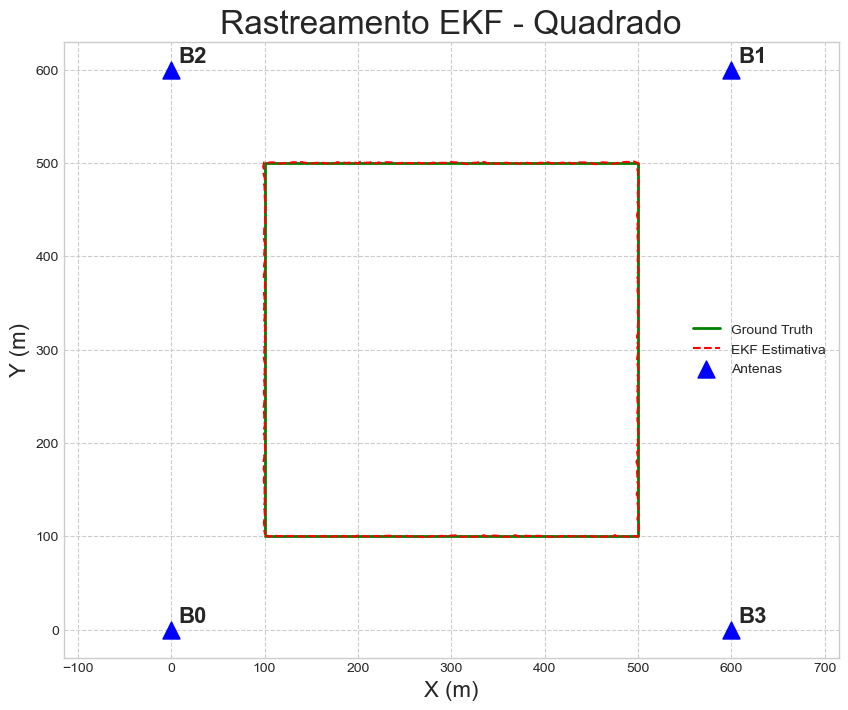

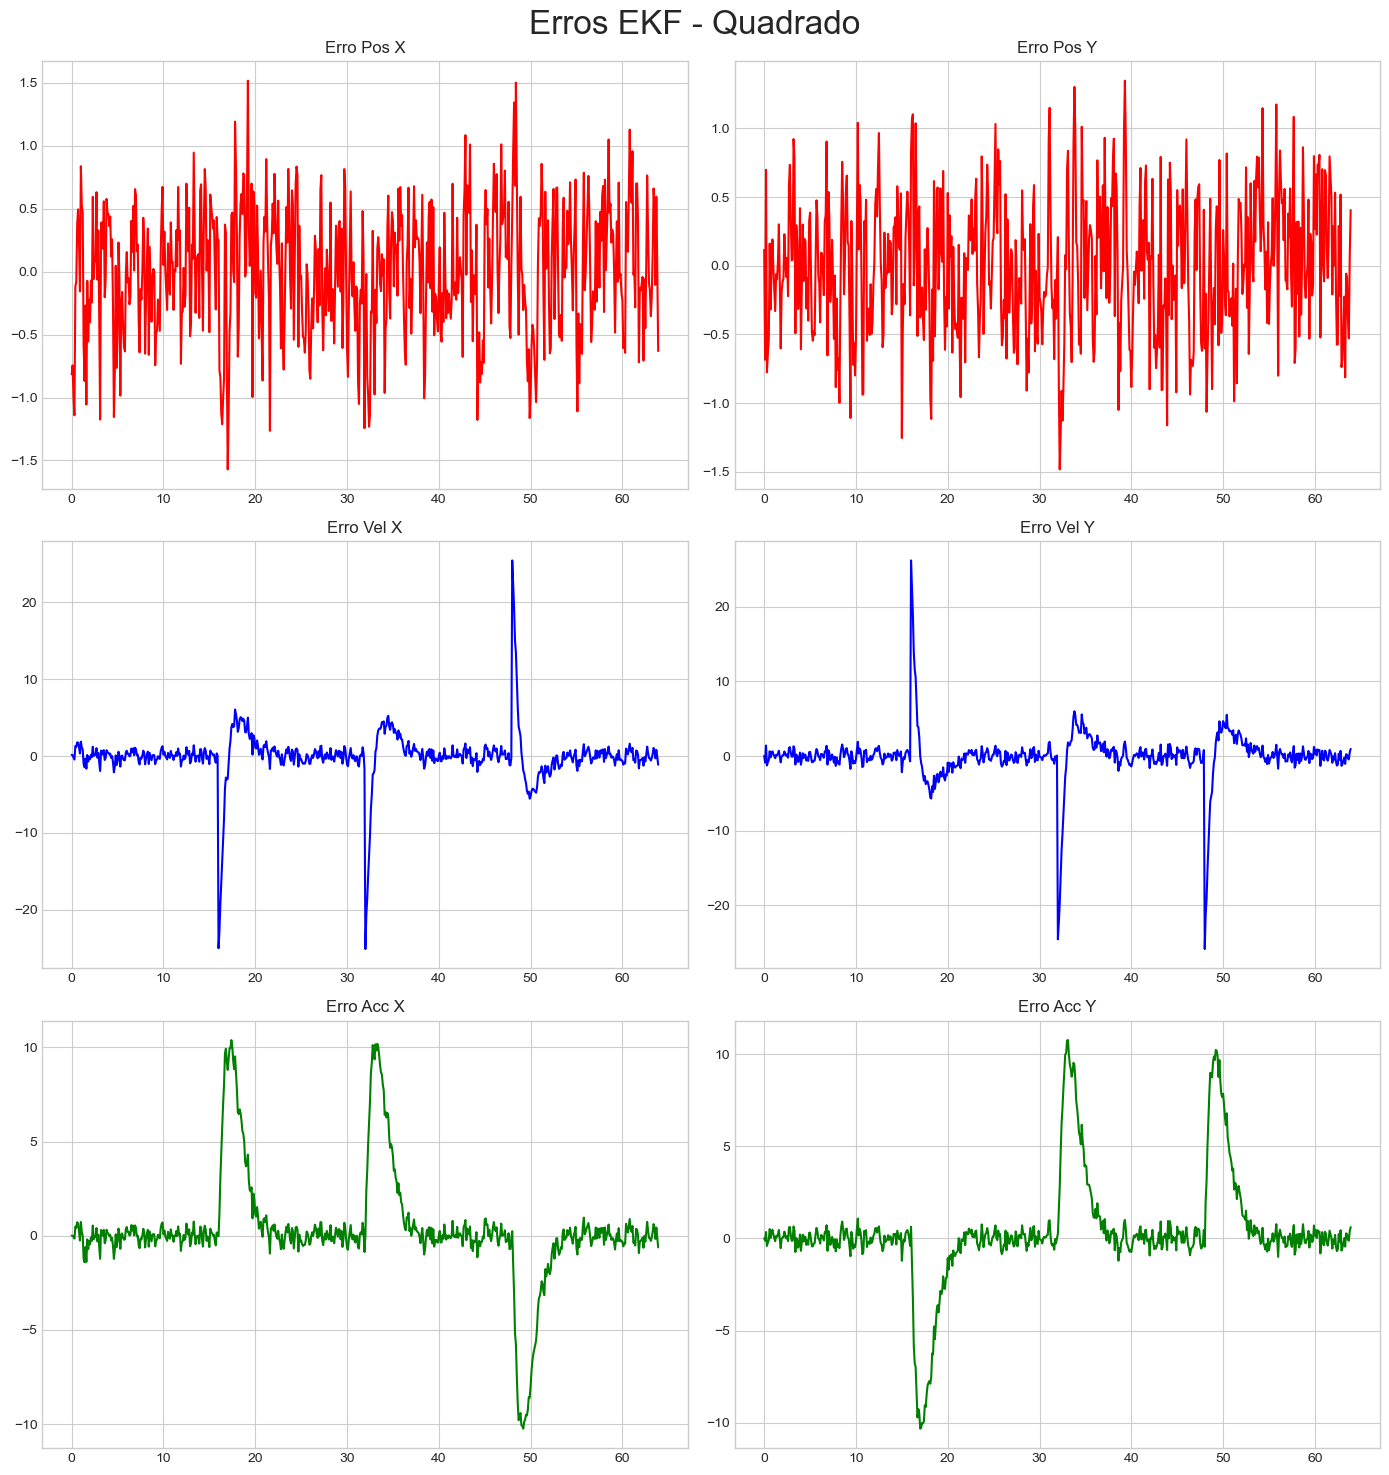


 RESULTADOS: Quadrado
RMS Posição   : 0.6979 m
RMS Velocidade: 4.8908 m/s
RMS Aceleração: 4.1497 m/s²


--- Jacobianos Médios ---
F_medio:
[[1.    0.    0.1   0.    0.005 0.   ]
 [0.    1.    0.    0.1   0.    0.005]
 [0.    0.    1.    0.    0.1   0.   ]
 [0.    0.    0.    1.    0.    0.1  ]
 [0.    0.    0.    0.    1.    0.   ]
 [0.    0.    0.    0.    0.    1.   ]]
H_medio:
[[ 0.656305    0.65634653  0.          0.          0.          0.        ]
 [-0.65631425 -0.65636523  0.          0.          0.          0.        ]
 [ 0.65632756 -0.65630312  0.          0.          0.          0.        ]
 [-0.65633967  0.65629633  0.          0.          0.          0.        ]]

 INICIANDO: Adaptativo_quadrado
Usando dados externos: N=640 amostras.
=== Análise de Identificabilidade das Matrizes de Ruído ===

Grau do polinômio mínimo (m): 3
Coeficientes a_i: [ 1. -3.  3. -1.]

Dimensão da matriz I: (64, 31)
Posto de I: 21

Parâmetros livres em Q (simétrica): 21
Parâmetros livres em R (sim

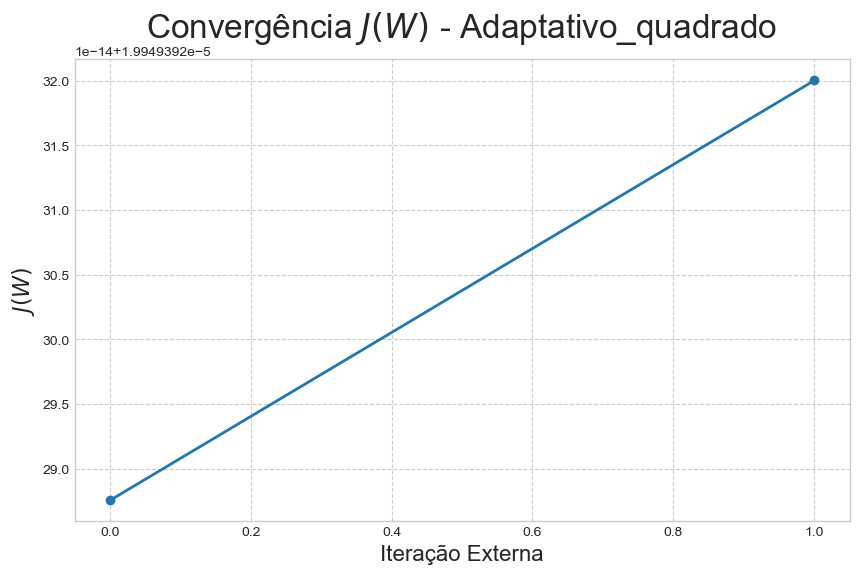

Teste NIS: 97.50% dos pontos estão dentro do intervalo de 95% de confiança.


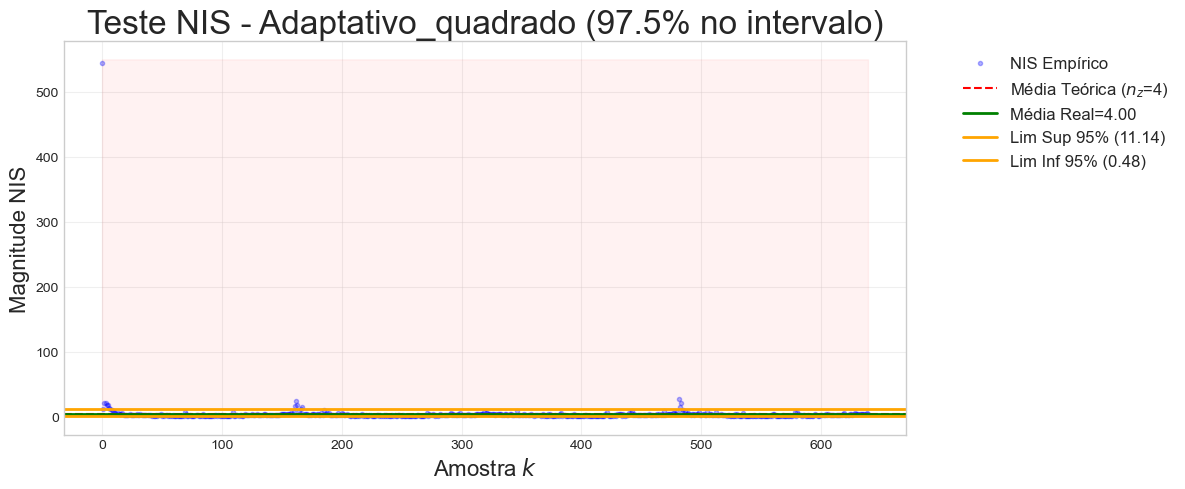


--- ANÁLISE DE COVARIÂNCIA DA INOVAÇÃO (S) ---
S Estimado Empírico:
 [[208015.118318 207711.114833 206632.853554 206632.582558]
 [207711.114833 207999.042964 206625.166221 206625.486732]
 [206632.853554 206625.166221 207895.845282 207892.445174]
 [206632.582558 206625.486732 207892.445174 207893.692629]]
S Ótimo Empírico:
 [[208029.022398 207697.009988 206632.667843 206632.524706]
 [207697.009988 208013.348579 206625.12372  206625.772805]
 [206632.667843 206625.12372  207895.780137 207892.410489]
 [206632.524706 206625.772805 207892.410489 207893.827151]]
S Teórico (DARE):
 [[ 1.826177e+00 -8.261950e-01 -8.000000e-06 -4.000000e-06]
 [-8.261950e-01  1.826212e+00  1.400000e-05 -2.000000e-06]
 [-8.000000e-06  1.400000e-05  1.826166e+00 -8.261700e-01]
 [-4.000000e-06 -2.000000e-06 -8.261700e-01  1.826173e+00]]

Estimativas finais:
Q estimado:
 [[ 44.16524386  43.39915542  70.55223866  69.32837019  39.65313722
   38.96523541]
 [ 43.39915542  43.99654443  69.32832882  70.28274072  38.965200

In [91]:
# =========================================================
# Configuração do cenário
# =========================================================
dT_sim = 0.1
antenas_base = np.array([[0,0], [600,600], [0,600], [600,0]])
gen = TrajectoryGenerator(dT_sim, antenas_base)
t_sim, traj_gt = gen.generate_square(side_length=400, bottom_left=(100, 100), linear_velocity=25)

# Construção de Q verdadeiro (6x6)
q_diag = [4.0, 4.0, 4.0, 4.0, 4.0, 4.0]   # pos, pos, vel, vel, acc, acc
Q_true = get_Q_disc_PVA(q_diag, dT_sim)

# Construção de R verdadeiro (diagonal, 4x4 pois 4 antenas)
dp = 1.0
desvios = np.full(len(antenas_base), dp)
R_true = create_cov(desvios)

# Estado inicial
x0 = np.array([traj_gt[0,0], traj_gt[0,1],traj_gt[0,2],traj_gt[0,3], traj_gt[0,4], traj_gt[0,5]]).reshape(-1,1)
P0 = np.eye(6) * 10.0

# Gamma (mantido para compatibilidade com algoritmo adaptativo)
# Como agora Q é 6x6, o adaptativo pode precisar de Gamma = I_6 ou ajuste interno.
# Sugiro definir Gamma como identidade:
Gamma = np.eye(6)

# Funções com dt fixo
f_func = partial(f_pva, dt=dT_sim)
F_jac_func = partial(F_jac_pva, dt=dT_sim)

# Chamada do wrapper
resultados, estados_est, _ = wrapper_adaptativo_ekf(
    nome_teste="quadrado",
    t_sim=t_sim,
    traj_gt=traj_gt,
    antenas_base=antenas_base,
    f_func=partial(f_pva, dt=dT_sim),
    F_jac=partial(F_jac_pva, dt=dT_sim),
    h_func=h_pva,
    H_jac=H_jac_pva,
    Q_true=Q_true,
    R_true=R_true,
    x0=x0,
    P0=P0,
    Gamma=Gamma,
    dT_sim=dT_sim,
    M_lags=10,
    max_outer=30
)

# Acesso aos resultados
W_est, R_est, Q_est, P_est, history, Imat = resultados
print("\nEstimativas finais:")
print("Q estimado:\n", Q_est)
print("R estimado:\n", R_est)

### Exemplo 2- Trajetória Circular

Iniciando simulação para: Circulo com 4 antenas...


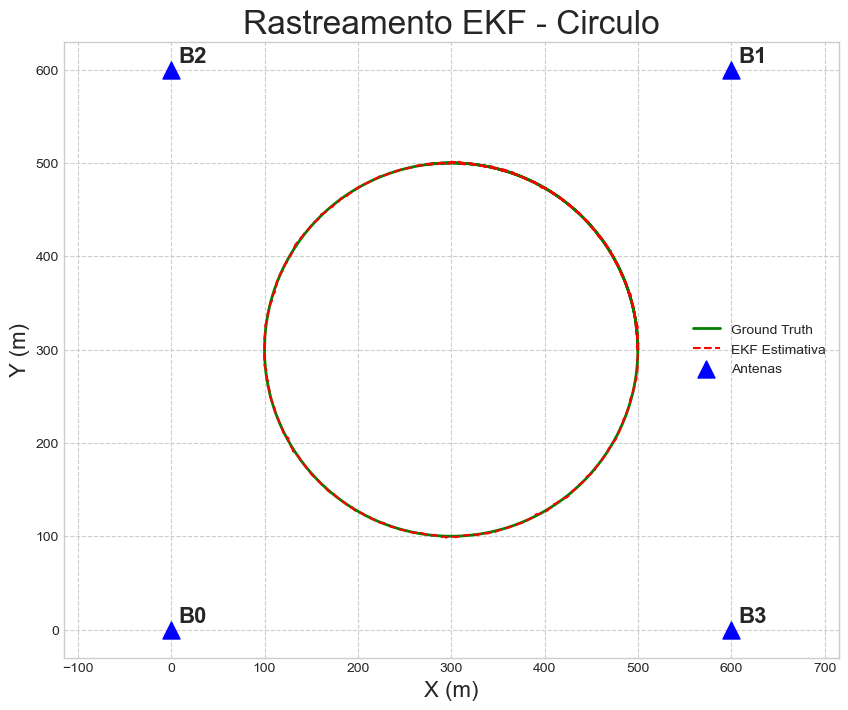

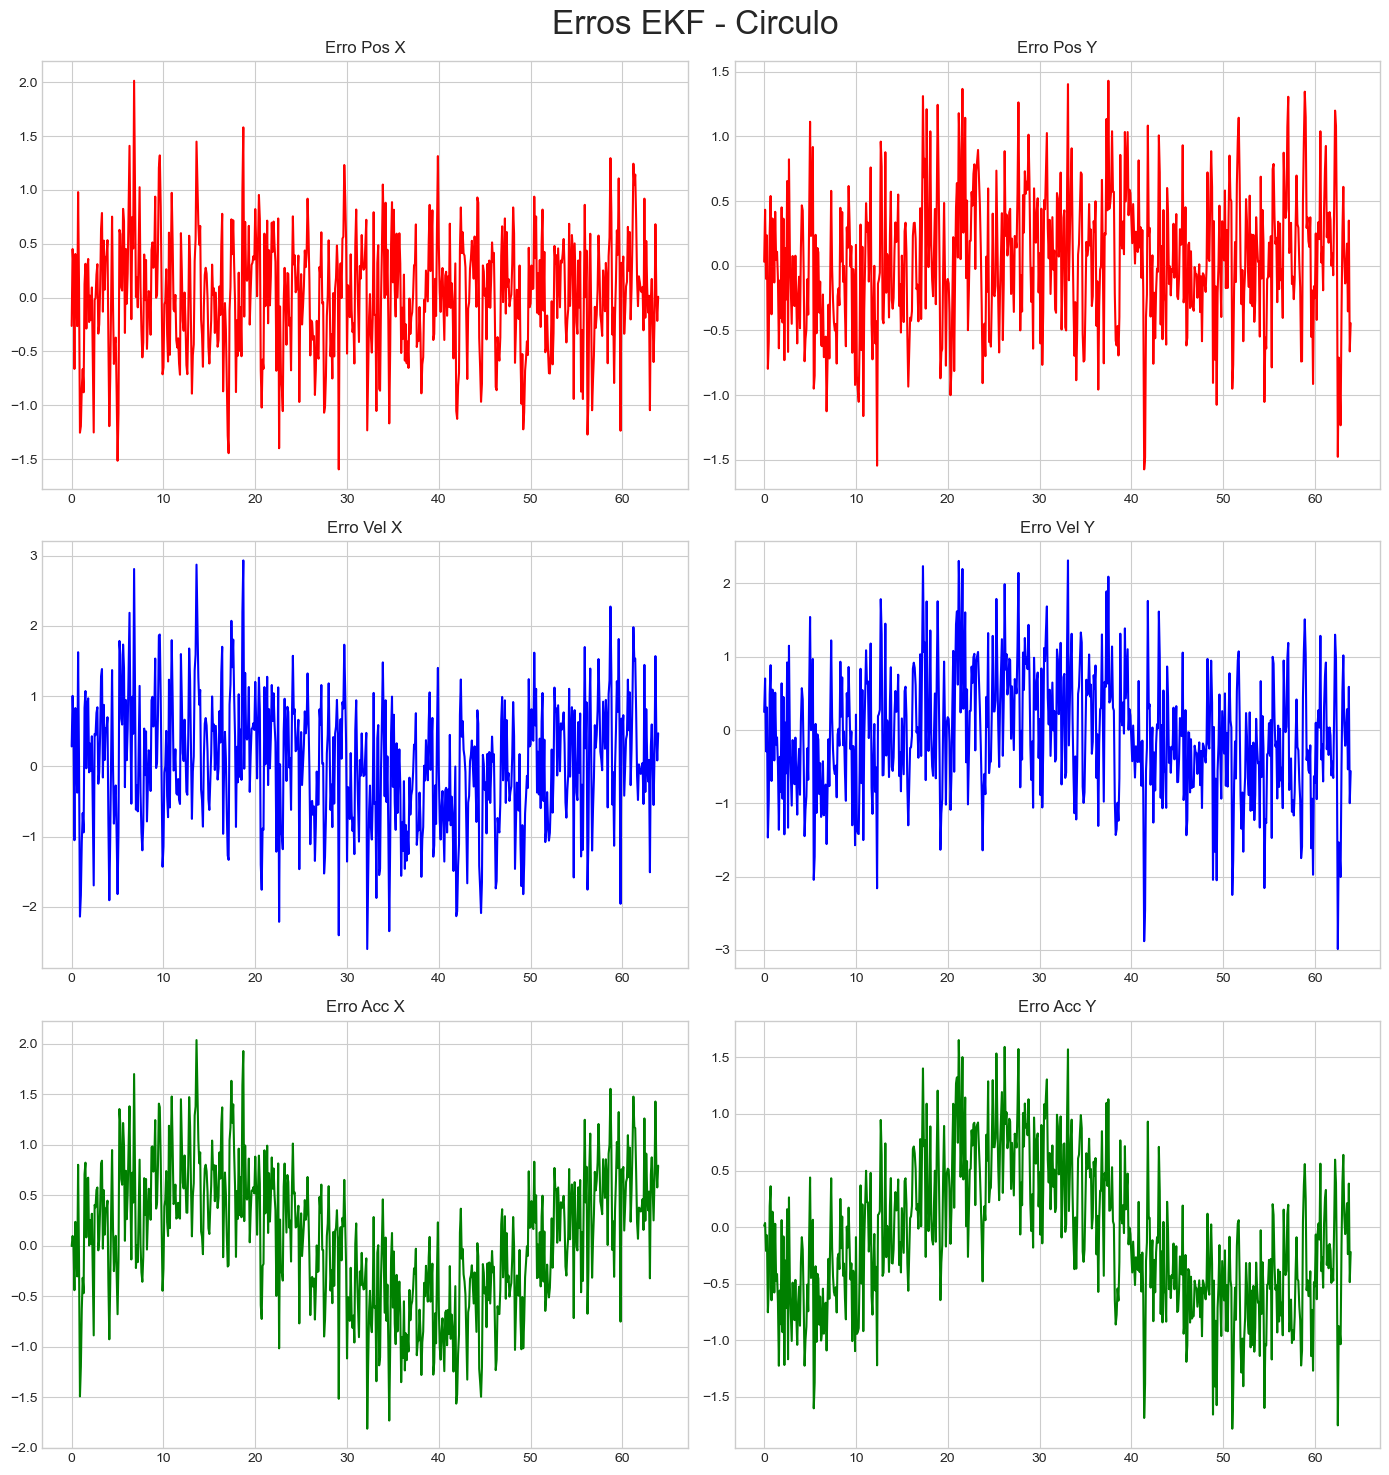


 RESULTADOS: Circulo
RMS Posição   : 0.7457 m
RMS Velocidade: 1.2219 m/s
RMS Aceleração: 0.9327 m/s²


--- Jacobianos Médios ---
F_medio:
[[1.    0.    0.1   0.    0.005 0.   ]
 [0.    1.    0.    0.1   0.    0.005]
 [0.    0.    1.    0.    0.1   0.   ]
 [0.    0.    0.    1.    0.    0.1  ]
 [0.    0.    0.    0.    1.    0.   ]
 [0.    0.    0.    0.    0.    1.   ]]
H_medio:
[[ 0.66990141  0.67601811  0.          0.          0.          0.        ]
 [-0.67202658 -0.66123962  0.          0.          0.          0.        ]
 [ 0.72256334 -0.60051181  0.          0.          0.          0.        ]
 [-0.60387222  0.72089478  0.          0.          0.          0.        ]]

 INICIANDO: Adaptativo_circulo
Usando dados externos: N=640 amostras.
=== Análise de Identificabilidade das Matrizes de Ruído ===

Grau do polinômio mínimo (m): 3
Coeficientes a_i: [ 1. -3.  3. -1.]

Dimensão da matriz I: (64, 31)
Posto de I: 21

Parâmetros livres em Q (simétrica): 21
Parâmetros livres em R (simét

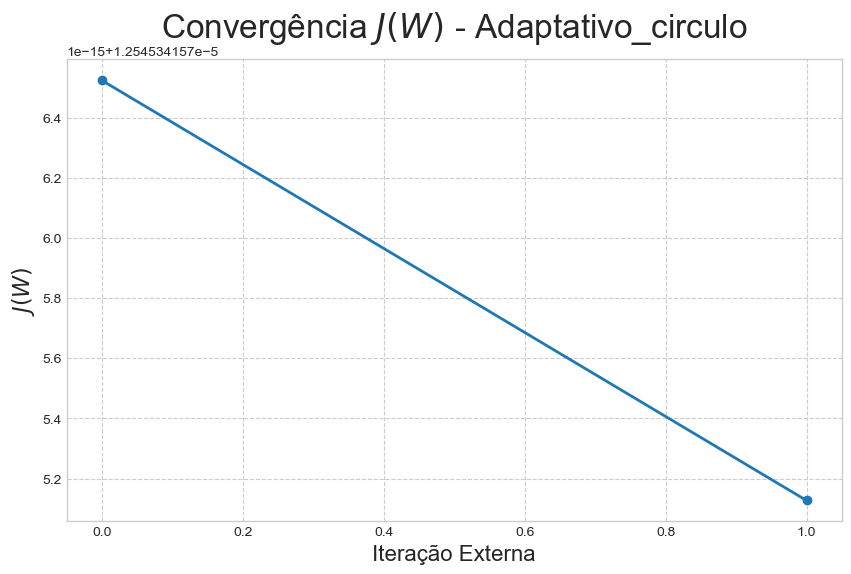

Teste NIS: 99.06% dos pontos estão dentro do intervalo de 95% de confiança.


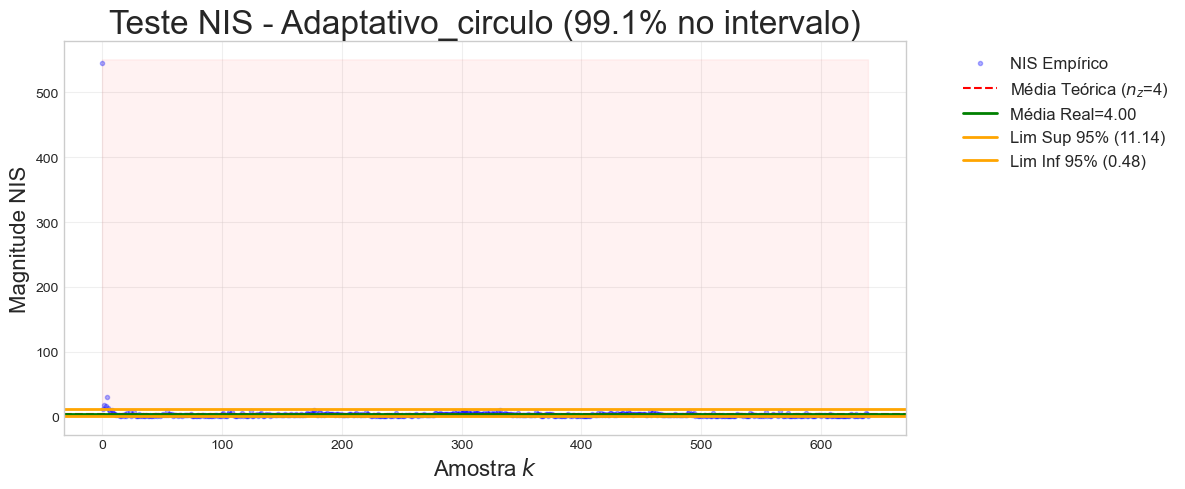


--- ANÁLISE DE COVARIÂNCIA DA INOVAÇÃO (S) ---
S Estimado Empírico:
 [[162998.708566 196509.721801 180176.016119 177508.596634]
 [196509.721801 237218.517805 217455.531454 214420.853953]
 [180176.016119 217455.531454 200303.05213  197369.813953]
 [177508.596634 214420.853953 197369.813953 194609.04494 ]]
S Ótimo Empírico:
 [[163002.909533 196504.580939 180179.886466 177504.213504]
 [196504.580939 237224.568627 217452.055445 214424.659409]
 [180179.886466 217452.055445 200306.933984 197366.845084]
 [177504.213504 214424.659409 197366.845084 194610.785792]]
S Teórico (DARE):
 [[ 1.852828 -0.844747  0.072355  0.079134]
 [-0.844747  1.836878 -0.082291 -0.067758]
 [ 0.072355 -0.082291  1.840726 -0.828256]
 [ 0.079134 -0.067758 -0.828256  1.842694]]

Estimativas finais:
Q estimado:
 [[ 49.97879587   6.57339132  79.88212084  10.53261454  44.89286601
    5.92350467]
 [  6.57339132   1.53713229  10.49692671   2.4591209    5.89377833
    1.38199207]
 [ 79.88212084  10.49692671 131.99964414  17.

In [89]:
# =========================================================
# Configuração do cenário
# =========================================================
dT_sim = 0.1
antenas_base = np.array([[0,0], [600,600], [0,600], [600,0]])
gen = TrajectoryGenerator(dT_sim, antenas_base)
t_sim, traj_gt = gen.generate_circle(radius=200, center=(300,300), linear_velocity=25, duration=64)

# Construção de Q verdadeiro (6x6)
q_diag = [4.0, 4.0, 4.0, 4.0, 4.0, 4.0]   # pos, pos, vel, vel, acc, acc
Q_true = get_Q_disc_PVA(q_diag, dT_sim)

# Construção de R verdadeiro (diagonal, 4x4 pois 4 antenas)
dp = 1.0
desvios = np.full(len(antenas_base), dp)
R_true = create_cov(desvios)

# Estado inicial
x0 = np.array([traj_gt[0,0], traj_gt[0,1],traj_gt[0,2],traj_gt[0,3], traj_gt[0,4], traj_gt[0,5]]).reshape(-1,1)
P0 = np.eye(6) * 10.0

# Gamma (mantido para compatibilidade com algoritmo adaptativo)
# Como agora Q é 6x6, o adaptativo pode precisar de Gamma = I_6 ou ajuste interno.
# Sugiro definir Gamma como identidade:
Gamma = np.eye(6)
# Funções com dt fixo
f_func = partial(f_pva, dt=dT_sim)
F_jac_func = partial(F_jac_pva, dt=dT_sim)


# Chamada do wrapper
resultados, estados_est, _ = wrapper_adaptativo_ekf(
    nome_teste="circulo",
    t_sim=t_sim,
    traj_gt=traj_gt,
    antenas_base=antenas_base,
    f_func=partial(f_pva, dt=dT_sim),
    F_jac=partial(F_jac_pva, dt=dT_sim),
    h_func=h_pva,
    H_jac=H_jac_pva,
    Q_true=Q_true,
    R_true=R_true,
    x0=x0,
    P0=P0,
    Gamma=Gamma,
    dT_sim=dT_sim,
    M_lags=10,
    max_outer=30
)

# Acesso aos resultados
W_est, R_est, Q_est, P_est, history, Imat = resultados
print("\nEstimativas finais:")
print("Q estimado:\n", Q_est)
print("R estimado:\n", R_est)

### Exemplo 2- Trajetória Curva -s

Iniciando simulação para: Curva-s com 4 antenas...


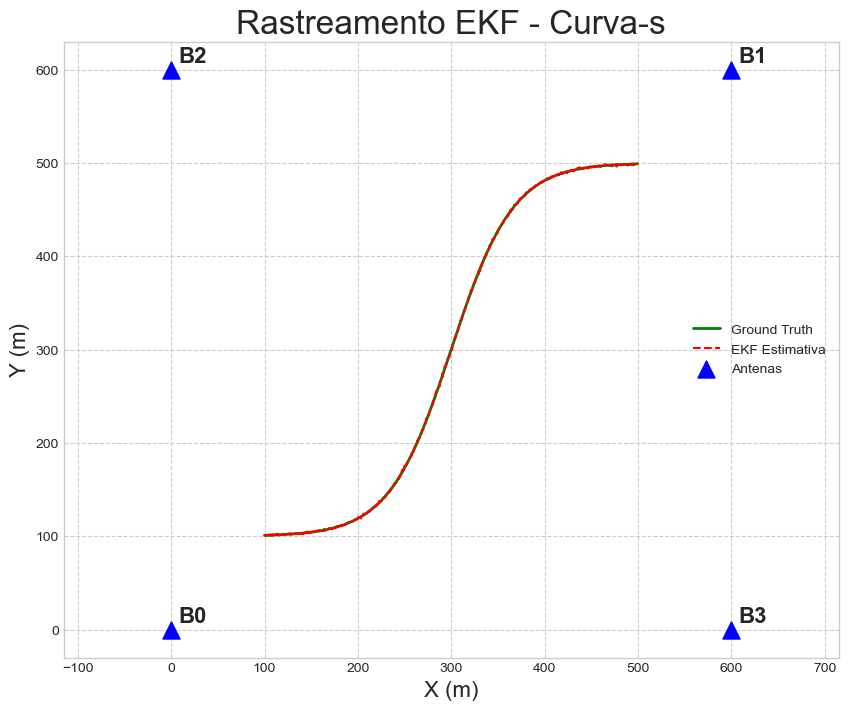

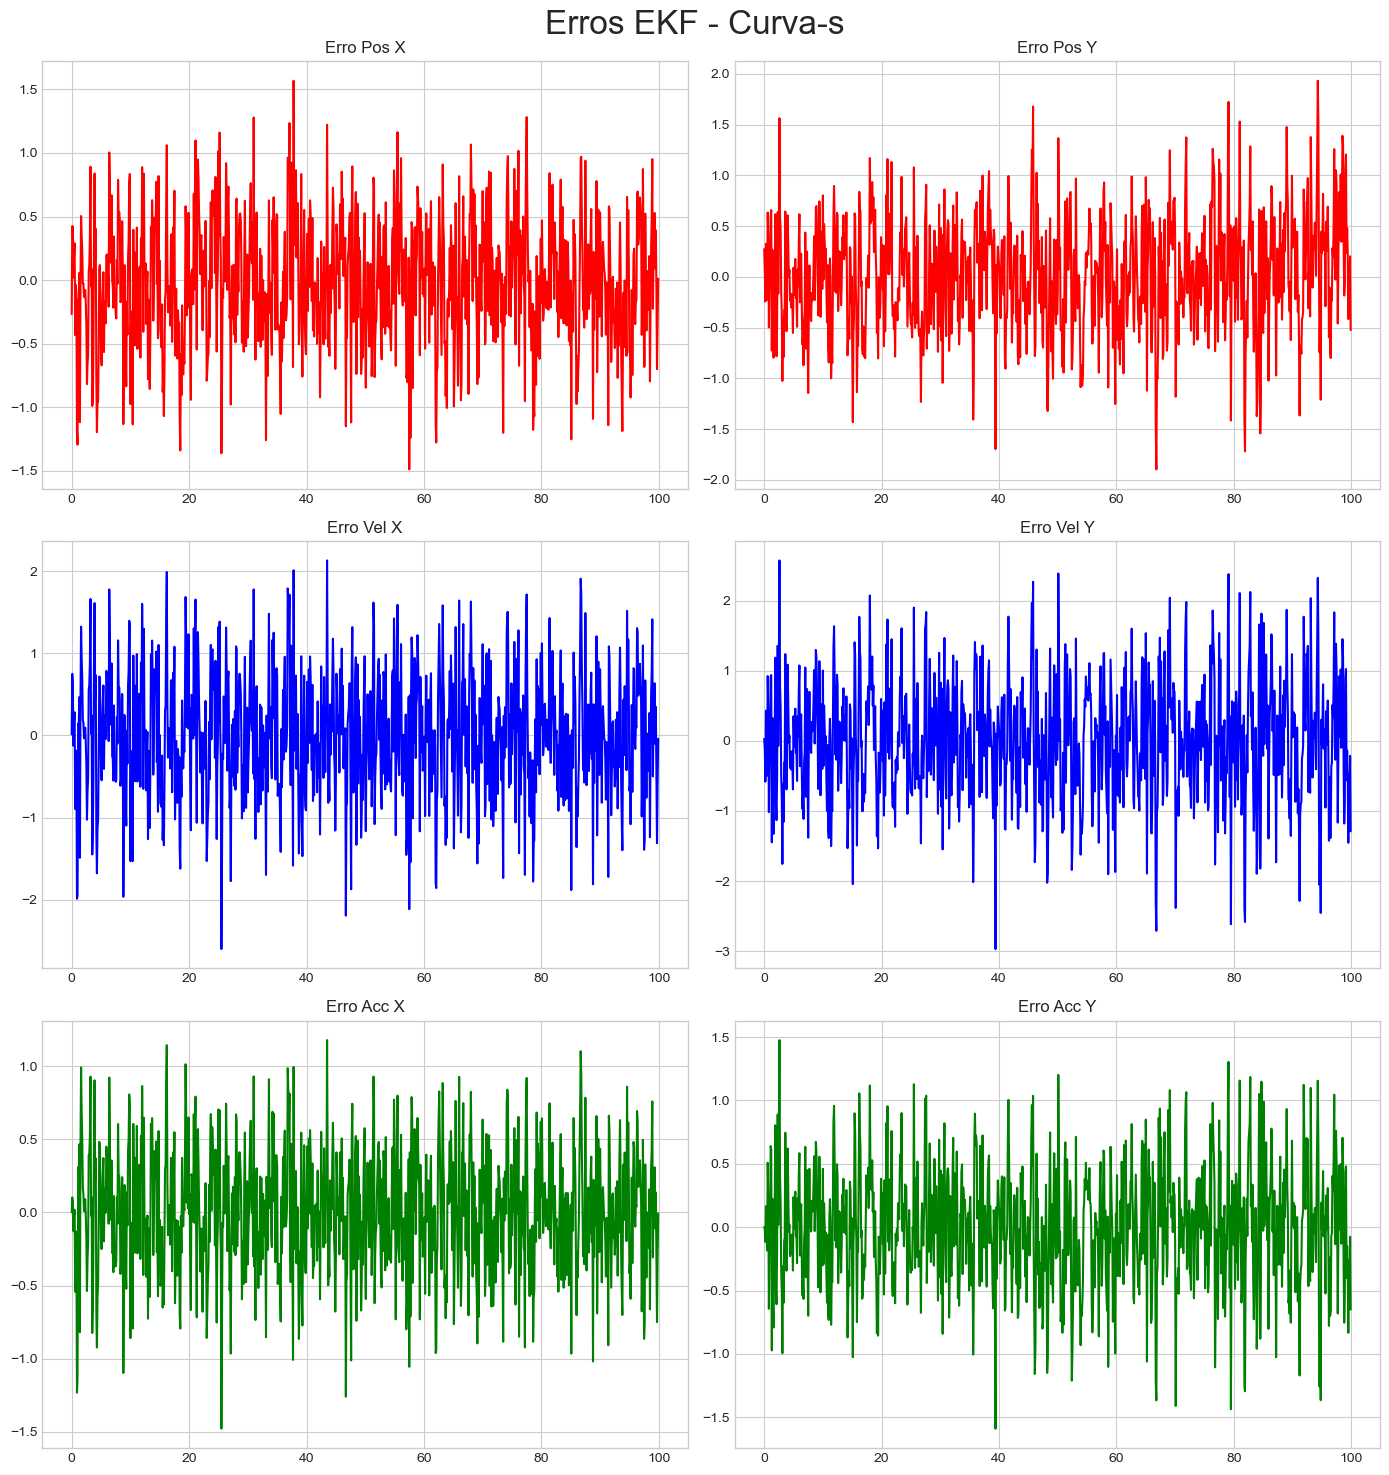


 RESULTADOS: Curva-s
RMS Posição   : 0.7303 m
RMS Velocidade: 1.1190 m/s
RMS Aceleração: 0.6189 m/s²


--- Jacobianos Médios ---
F_medio:
[[1.    0.    0.1   0.    0.005 0.   ]
 [0.    1.    0.    0.1   0.    0.005]
 [0.    0.    1.    0.    0.1   0.   ]
 [0.    0.    0.    1.    0.    0.1  ]
 [0.    0.    0.    0.    1.    0.   ]
 [0.    0.    0.    0.    0.    1.   ]]
H_medio:
[[ 0.73406802  0.66725351  0.          0.          0.          0.        ]
 [-0.73393833 -0.66740339  0.          0.          0.          0.        ]
 [ 0.66352091 -0.62468754  0.          0.          0.          0.        ]
 [-0.66425643  0.62390373  0.          0.          0.          0.        ]]

 INICIANDO: Adaptativo_curva-s
Usando dados externos: N=1000 amostras.
=== Análise de Identificabilidade das Matrizes de Ruído ===

Grau do polinômio mínimo (m): 3
Coeficientes a_i: [ 1. -3.  3. -1.]

Dimensão da matriz I: (64, 31)
Posto de I: 21

Parâmetros livres em Q (simétrica): 21
Parâmetros livres em R (simé

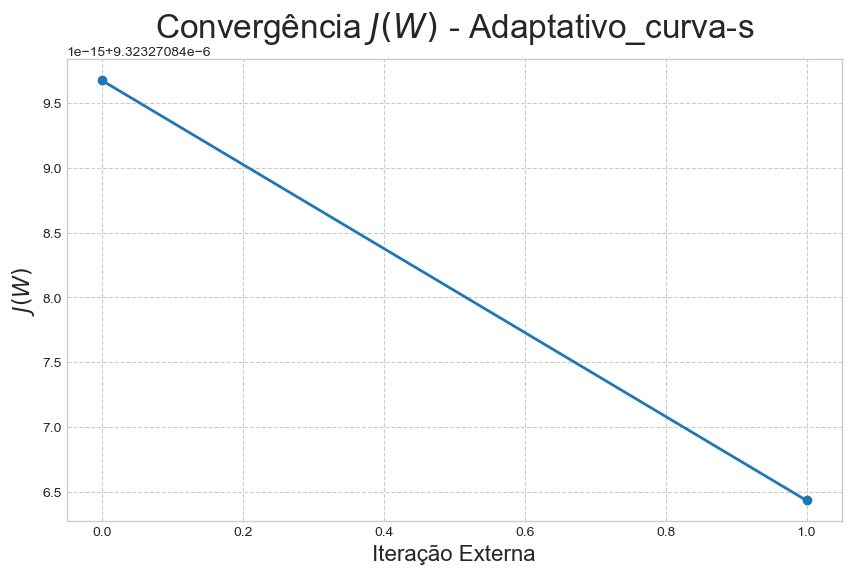

Teste NIS: 98.80% dos pontos estão dentro do intervalo de 95% de confiança.


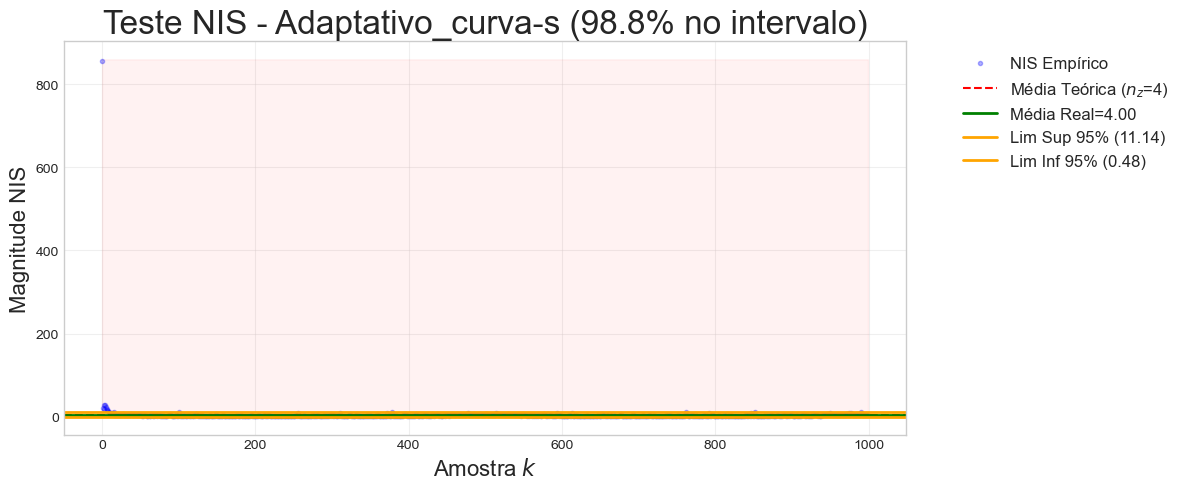


--- ANÁLISE DE COVARIÂNCIA DA INOVAÇÃO (S) ---
S Estimado Empírico:
 [[182572.972056 182165.195658 199302.893601 199362.208574]
 [182165.195658 182132.337233 199061.0666   199120.081308]
 [199302.893601 199061.0666   218401.541945 218464.401007]
 [199362.208574 199120.081308 218464.401007 218531.40847 ]]
S Ótimo Empírico:
 [[182581.122306 182157.184273 199302.701112 199362.437151]
 [182157.184273 182140.209758 199061.28447  199119.827207]
 [199302.701112 199061.28447  218401.465728 218464.504847]
 [199362.437151 199119.827207 218464.504847 218531.276921]]
S Teórico (DARE):
 [[ 1.897764 -0.897773  0.041211 -0.042183]
 [-0.897773  1.897783 -0.041036  0.042007]
 [ 0.041211 -0.041036  1.807391 -0.80736 ]
 [-0.042183  0.042007 -0.80736   1.80733 ]]

Estimativas finais:
Q estimado:
 [[25.30573385 25.38847657 40.52665912 40.50330174 22.75467395 22.71182453]
 [25.38847657 26.6970087  40.70946581 42.64514201 22.88363469 23.94424814]
 [40.52665912 40.70946581 66.81302091 66.9500575  37.70235386

In [90]:
# =========================================================
# Configuração do cenário
# =========================================================
dT_sim = 0.1
antenas_base = np.array([[0,0], [600,600], [0,600], [600,0]])
gen = TrajectoryGenerator(dT_sim, antenas_base)
t_sim, traj_gt = gen.generate_tanh_curve(start_pos=(100, 100), end_pos=(500, 500), 
                                               amplitude_y=200, smoothness=6.0, duration=100)
# Construção de Q verdadeiro (6x6)
q_diag = [4.0, 4.0, 4.0, 4.0, 4.0, 4.0]   # pos, pos, vel, vel, acc, acc
Q_true = get_Q_disc_PVA(q_diag, dT_sim)

# Construção de R verdadeiro (diagonal, 4x4 pois 4 antenas)
dp = 1.0
desvios = np.full(len(antenas_base), dp)
R_true = create_cov(desvios)

# Estado inicial
x0 = np.array([traj_gt[0,0], traj_gt[0,1],traj_gt[0,2],traj_gt[0,3], traj_gt[0,4], traj_gt[0,5]]).reshape(-1,1)
P0 = np.eye(6) * 10.0

# Gamma (mantido para compatibilidade com algoritmo adaptativo)
# Como agora Q é 6x6, o adaptativo pode precisar de Gamma = I_6 ou ajuste interno.
# Sugiro definir Gamma como identidade:
Gamma = np.eye(6)

# Funções com dt fixo
f_func = partial(f_pva, dt=dT_sim)
F_jac_func = partial(F_jac_pva, dt=dT_sim)


# Chamada do wrapper
resultados, estados_est, _ = wrapper_adaptativo_ekf(
    nome_teste="curva-s",
    t_sim=t_sim,
    traj_gt=traj_gt,
    antenas_base=antenas_base,
    f_func=partial(f_pva, dt=dT_sim),
    F_jac=partial(F_jac_pva, dt=dT_sim),
    h_func=h_pva,
    H_jac=H_jac_pva,
    Q_true=Q_true,
    R_true=R_true,
    x0=x0,
    P0=P0,
    Gamma=Gamma,
    dT_sim=dT_sim,
    M_lags=10,
    max_outer=30
)

# Acesso aos resultados
W_est, R_est, Q_est, P_est, history, Imat = resultados
print("\nEstimativas finais:")
print("Q estimado:\n", Q_est)
print("R estimado:\n", R_est)